In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import datasets, transforms, utils
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import glob
import random
import json
import os

In [ ]:
# Set random seeds for reproducibility
SEED = 42
print("Random Seed:", SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Select device: use GPU if available, else CPU
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Random Seed: 42
Using device: cuda:1


In [ ]:
# Load run configuration from file so parameters are easy to edit.
config_path = Path('configs/notebook_gan_config.json')
with open(config_path, 'r', encoding='utf-8') as f:
    cfg = json.load(f)

dataset_choice = cfg.get('dataset_choice', 'vae')
nn_choice = cfg.get('nn_choice', 'mlp')

batch_size = int(cfg.get('batch_size', 128))
z_dim = int(cfg.get('z_dim', 64))
lr_D = float(cfg.get('lr_D', 0.0004))
lr_G = float(cfg.get('lr_G', 0.0002))
num_epochs = int(cfg.get('num_epochs', 15))

print(f'Loaded config from: {config_path}')
print(f'dataset_choice={dataset_choice}, nn_choice={nn_choice}, batch_size={batch_size}, z_dim={z_dim}, epochs={num_epochs}')

In [ ]:
# ------------------------------------------------------------
# 1) Experiment switches (edit these to control the run)
# ------------------------------------------------------------

# dataset_choice and nn_choice are loaded from configs/notebook_gan_config.json


# ------------------------------------------------------------
# 2) Dataset-dependent preprocessing + hyperparameters
# ------------------------------------------------------------
# We set:
# - image_size   : final H=W passed into the model (may resize original images)
# - channels_img : number of channels (1 for grayscale, 3 for RGB)
# - hidden_dim   : example model capacity knob (used by your model definition elsewhere)
# - transform    : preprocessing pipeline applied to every image sample
# - dataset      : torchvision dataset object (downloads if missing)

if dataset_choice == 'vae':
    # Use CS424 domains as RGB image folders.
    # Both folders are combined into one training dataset for this GAN notebook.
    image_size = int(cfg.get('image_size', 64))
    channels_img = 3
    hidden_dim = int(cfg.get('hidden_dim_mlp', 256)) if nn_choice == 'mlp' else int(cfg.get('hidden_dim_cnn', 12))
    domain_a_train_root = cfg.get('domain_a_train', 'image_image_translation/image_image_translation/VAE_generation/train')
    domain_b_train_root = cfg.get('domain_b_train', 'image_image_translation/image_image_translation/VAE_generation1/train')

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ])

    class FlatImageDataset(Dataset):
        def __init__(self, root, transform=None):
            self.root = Path(root)
            self.transform = transform
            self.files = sorted([p for p in self.root.glob('*') if p.is_file()])
            if len(self.files) == 0:
                raise ValueError(f'No files found in {self.root}')

        def __len__(self):
            return len(self.files)

        def __getitem__(self, idx):
            path = self.files[idx]
            img = Image.open(path).convert('RGB')
            if self.transform is not None:
                img = self.transform(img)
            return img, 0

    domain_a_train = FlatImageDataset(
        root=domain_a_train_root,
        transform=transform,
    )
    domain_b_train = FlatImageDataset(
        root=domain_b_train_root,
        transform=transform,
    )
    dataset = ConcatDataset([domain_a_train, domain_b_train])

else:
    raise ValueError("Invalid dataset_choice. Choose 'vae'.")


# ------------------------------------------------------------
# 3) DataLoader: batching + shuffling
# ------------------------------------------------------------
# DataLoader wraps the dataset to:
# - batch_size: number of samples per gradient update (tradeoff: speed vs memory vs stability)
# - shuffle=True: randomize sample order each epoch (reduces bias from fixed ordering)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# ------------------------------------------------------------
# MLP-based Generator (for GAN)
# ------------------------------------------------------------
# This generator maps a latent noise vector z -> a flattened image vector.
# Key idea:
#   noise z  (batch_size, z_dim)
#        -> several fully-connected layers (MLP)
#        -> output (batch_size, im_dim) where im_dim = H*W*C (flattened pixels)
class MLP_Generator(nn.Module):
    def __init__(self, z_dim=64, im_dim=784, hidden_dim=128):
        """
        Args:
            z_dim (int): Dimension of latent noise vector z.
                        Larger z_dim can increase diversity, but also training difficulty.
            im_dim (int): Flattened image dimension = H*W*C.
            hidden_dim (int): Base hidden width controlling model capacity.
        """
        super(MLP_Generator, self).__init__()
        self.gen = nn.Sequential(
            self.get_mlp_gen_block(z_dim, hidden_dim),                  # (B, z_dim) -> (B, hidden_dim)
            self.get_mlp_gen_block(hidden_dim, hidden_dim * 2),         # (B, hidden_dim) -> (B, 2*hidden_dim)
            self.get_mlp_gen_block(hidden_dim * 2, hidden_dim * 4),     # -> (B, 4*hidden_dim)
            self.get_mlp_gen_block(hidden_dim * 4, hidden_dim * 8),     # -> (B, 8*hidden_dim)
            nn.Linear(hidden_dim * 8, im_dim),                          # final projection to flattened pixels
            nn.Tanh()                                                   # constrain pixels to [-1, 1]
        )

    def get_mlp_gen_block(self, input_dim, output_dim):
        """
        A reusable generator block: Linear -> BatchNorm -> ReLU.
        - Linear: learns an affine transform to increase representation capacity.
        - BatchNorm1d: stabilizes training by normalizing activations across the batch,
                       often helping GAN training (though it can interact with small batch sizes).
        - ReLU(inplace=True): nonlinearity; inplace saves a bit of memory.
        """
        return nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, noise):
        """
        Forward pass.

        Args:
            noise (Tensor): shape (batch_size, z_dim)

        Returns:
            Tensor: generated flattened images, shape (batch_size, im_dim)
                    Values are in [-1, 1].
        """
        return self.gen(noise)


In [ ]:
# ------------------------------------------------------------
# MLP-based Discriminator (for GAN)
# ------------------------------------------------------------
# The discriminator is a binary classifier:
#   input image (real or generated) -> output probability in [0, 1]
# where:
#   1 = "real", 0 = "fake" (by convention in many GAN tutorials)
class MLP_Discriminator(nn.Module):
    def __init__(self, im_dim=784, hidden_dim=128):
        """
        Args:
            im_dim (int): Flattened image dimension = H*W*C.
                          Must match the generator output dimension after flattening.
            hidden_dim (int): Base width controlling capacity.
        """
        super(MLP_Discriminator, self).__init__()

        # The discriminator compresses the high-dimensional image into a single logit/probability.
        # Architecture choice here:
        #   im_dim -> 4H -> 2H -> H -> 1
        # This "funnel" shape encourages the network to extract progressively more abstract features.
        self.disc = nn.Sequential(
            self.get_mlp_disc_block(im_dim, hidden_dim * 4),        # (B, im_dim) -> (B, 4H)
            self.get_mlp_disc_block(hidden_dim * 4, hidden_dim * 2),# -> (B, 2H)
            self.get_mlp_disc_block(hidden_dim * 2, hidden_dim),    # -> (B, H)
            nn.Linear(hidden_dim, 1),                               # -> (B, 1) logit
            nn.Sigmoid()                                            # -> probability in [0, 1]
        )
    def get_mlp_disc_block(self, input_dim, output_dim):
        """
        A reusable discriminator block: Linear -> LeakyReLU.
        - LeakyReLU allows a small, non-zero gradient when the unit is "off" (negative input),
          helping avoid dead neurons and often improving GAN discriminator training stability.
        - Negative slope 0.2 is a common default in GAN literature/tutorials.
        """
        return nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def flatten_img(self, image):
        """
        Flatten an image tensor to a vector per example.

        Input:
            image: (B, C, H, W) or already flattened (B, im_dim)
        Output:
            (B, C*H*W)
        """
        return image.view(image.size(0), -1)

    def forward(self, image):
        """
        Forward pass.

        Args:
            image (Tensor): real or fake images.
                           Common shapes:
                           - (B, 1, 28, 28) for MNIST
                           - (B, 3, 32, 32) for CIFAR-10
                           - or already flattened (B, im_dim)

        Returns:
            Tensor: probabilities of being real, shape (B, 1), values in [0, 1].
        """
        image = self.flatten_img(image)   # ensure MLP input is a flat vector
        return self.disc(image)


In [ ]:
# ------------------------------------------------------------
# CNN-based Generator (DCGAN-style)
# ------------------------------------------------------------
# This generator maps a latent noise vector z -> an image tensor using transposed convolutions.
#
# Main idea:
#   noise z: (B, z_dim)
#     -> reshape to (B, z_dim, 1, 1)  (treat z as "channels" of a 1x1 feature map)
#     -> ConvTranspose2d blocks that upsample spatially (1x1 -> 4x4 -> 8x8 -> 16x16 -> 32x32)
#     -> output image: (B, im_chan, H, W) with values in [-1, 1] due to Tanh
class CNN_Generator(nn.Module):
    def __init__(self, z_dim=10, im_chan=1, hidden_dim=64):
        """
        Args:
            z_dim (int): Dimension of latent noise vector.
                         Common values: 64, 100, 128.
                         (z_dim=10 is small; can work but may reduce diversity.)
            im_chan (int): Output image channels:
                           1 for grayscale (MNIST), 3 for RGB (CIFAR-10).
            hidden_dim (int): Base channel width for feature maps.
        """
        super(CNN_Generator, self).__init__()
        self.z_dim = z_dim
        # Generator network as a stack of upsampling blocks.
        # Channel schedule (with default hidden_dim=64):
        #   z_dim -> 256 -> 128 -> 64 -> im_chan
        # Spatial schedule (with default params shown):
        #   (1x1) --k4,s1,p0--> (4x4)
        #   (4x4) --k4,s2,p1--> (8x8)
        #   (8x8) --k4,s2,p1--> (16x16)
        #   (16x16) --k4,s2,p1--> (32x32)  final image size
        self.gen = nn.Sequential(
            # First block uses stride=1,padding=0 to go from 1x1 -> 4x4 directly
            self.get_cnn_gen_block(z_dim, hidden_dim * 4, stride=1, padding=0),

            # Subsequent blocks double spatial resolution each time (stride=2, padding=1 by default)
            self.get_cnn_gen_block(hidden_dim * 4, hidden_dim * 2),  # 4x4 -> 8x8
            self.get_cnn_gen_block(hidden_dim * 2, hidden_dim),      # 8x8 -> 16x16

            # Final layer outputs an image with im_chan channels, uses Tanh instead of BN+ReLU
            self.get_cnn_gen_block(hidden_dim, im_chan, final_layer=True)  # 16x16 -> 32x32
        )

    def get_cnn_gen_block(
        self,
        input_dim,
        output_dim,
        kernel_size=4,
        stride=2,
        padding=1,
        final_layer=False
    ):
        """
        Builds one generator block.

        Non-final block: ConvTranspose2d -> BatchNorm2d -> ReLU
        - ConvTranspose2d upsamples spatially while learning filters.
        - BatchNorm2d stabilizes training by normalizing feature maps.
        - ReLU provides nonlinearity; standard in DCGAN generators.

        Final block: ConvTranspose2d -> Tanh
        - No BatchNorm in last layer (common practice).
        - Tanh outputs in [-1, 1], matching normalized image range.
        """
        if not final_layer:
            return nn.Sequential(
                nn.ConvTranspose2d(input_dim, output_dim, kernel_size, stride, padding),
                nn.BatchNorm2d(output_dim),
                nn.ReLU()
            )
        else:
            return nn.Sequential(
                nn.ConvTranspose2d(input_dim, output_dim, kernel_size, stride, padding),
                nn.Tanh()
            )

    def unsqueeze_noise(self, noise):
        """
        Reshape noise vectors into 4D tensors expected by ConvTranspose2d.

        Input:
            noise: (B, z_dim)
        Output:
            (B, z_dim, 1, 1)
        """
        return noise.view(len(noise), self.z_dim, 1, 1)

    def forward(self, noise):
        """
        Forward pass.

        Args:
            noise (Tensor): shape (B, z_dim)

        Returns:
            Tensor: generated images, shape (B, im_chan, H, W)
                    With the default block settings, H=W=32.
        """
        x = self.unsqueeze_noise(noise)
        return self.gen(x)

In [ ]:
# ------------------------------------------------------------
# CNN-based Discriminator (DCGAN-style)
# ------------------------------------------------------------
# The discriminator is a binary classifier that outputs "realness".
# This CNN version takes an image tensor (B, C, H, W) and progressively
# downsamples spatial resolution while increasing channel depth:
#
#   (B, im_chan, 32, 32)
#     -> (B, 64, 16, 16)
#     -> (B, 128, 8, 8)
#     -> (B, 256, 4, 4)
#     -> (B, 1, 1, 1)   (final decision)
class CNN_Discriminator(nn.Module):
    def __init__(self, im_chan=1, hidden_dim=64):
        """
        Args:
            im_chan (int): Number of input image channels:
                           1 for grayscale (MNIST), 3 for RGB (CIFAR-10).
            hidden_dim (int): Base number of feature maps in the first conv layer.
                              Larger hidden_dim -> higher capacity, slower training.
        """
        super(CNN_Discriminator, self).__init__()
        # Default spatial behavior with (kernel=4, stride=2, padding=1):
        # - each block halves H and W: 32->16->8->4
        # The final block uses stride=1,padding=0 to collapse 4x4 -> 1x1
        self.disc = nn.Sequential(
            self.get_cnn_disc_block(im_chan, hidden_dim),                 # 32x32 -> 16x16
            self.get_cnn_disc_block(hidden_dim, hidden_dim * 2),         # 16x16 -> 8x8
            self.get_cnn_disc_block(hidden_dim * 2, hidden_dim * 4),     # 8x8  -> 4x4
            self.get_cnn_disc_block(hidden_dim * 4, 1, stride=1, padding=0, final_layer=True)  # 4x4 -> 1x1
        )

    def get_cnn_disc_block(
        self,
        input_dim,
        output_dim,
        kernel_size=4,
        stride=2,
        padding=1,
        final_layer=False
    ):
        """
        Non-final block: Conv2d -> BatchNorm2d -> LeakyReLU
        - Conv2d extracts local features while downsampling (when stride=2).
        - BatchNorm2d helps stabilize training by normalizing feature maps.
          (Teaching caveat: for GAN discriminators, BN is sometimes replaced by
           spectral norm / instance norm, but BN is fine for introductory DCGAN.)
        - LeakyReLU keeps a small gradient for negative inputs, improving stability.
        Final block: Conv2d -> Sigmoid
        - Conv2d reduces to 1 output channel (a single score per image).
        - Sigmoid converts score to probability in [0, 1].
        """
        if not final_layer:
            return nn.Sequential(
                nn.Conv2d(input_dim, output_dim, kernel_size, stride, padding),
                nn.BatchNorm2d(output_dim),
                nn.LeakyReLU(negative_slope=0.2)
            )
        else:
            return nn.Sequential(
                nn.Conv2d(input_dim, output_dim, kernel_size, stride, padding),
                nn.Sigmoid()
            )

    def forward(self, image):
        """
        Forward pass.

        Args:
            image (Tensor): shape (B, im_chan, H, W)
                            Typically (B, 1, 32, 32) for MNIST (resized) or
                            (B, 3, 32, 32) for CIFAR-10.

        Returns:
            Tensor: shape (B, 1) probabilities in [0, 1].
                    Internally, the CNN outputs (B, 1, 1, 1); we flatten to (B, 1).
        """
        disc_pred = self.disc(image)              # (B, 1, 1, 1) for 32x32 inputs
        return disc_pred.view(len(disc_pred), -1) # (B, 1)

In [ ]:
# Initialize the networks
def weights_init_mlp(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm1d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def weights_init_cnn(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

if nn_choice == 'mlp':
    im_dim = channels_img * image_size * image_size
    G = MLP_Generator(z_dim=z_dim, im_dim=im_dim, hidden_dim=hidden_dim).to(device)
    D = MLP_Discriminator(im_dim=im_dim, hidden_dim=hidden_dim).to(device)
    G.apply(weights_init_mlp), D.apply(weights_init_mlp)
else:
    G = CNN_Generator(z_dim=z_dim, im_chan=channels_img, hidden_dim=hidden_dim).to(device)
    D = CNN_Discriminator(im_chan=channels_img, hidden_dim=hidden_dim).to(device)
    G.apply(weights_init_cnn), D.apply(weights_init_cnn)


In [ ]:
# Define loss function, optimizers, and learning rate schedulers
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))
scheduler_D = lr_scheduler.StepLR(optimizer_D, step_size=5, gamma=0.9)
scheduler_G = lr_scheduler.StepLR(optimizer_G, step_size=5, gamma=0.9)

# Create lists for saving losses
G_losses, D_losses = [], []

# Create directories to save images and models
os.makedirs(f'images_{dataset_choice}_{nn_choice}', exist_ok=True)
os.makedirs(f'checkpoints_{dataset_choice}_{nn_choice}', exist_ok=True)

fixed_noise = torch.randn(64, z_dim, device=device)  # Fixed noise for consistent image generation

print("Starting Training Loop...")

# Save initial checkpoint and generated images before training
initial_epoch = 0
torch.save({
    'epoch': initial_epoch,
    'G_state_dict': G.state_dict(),
    'D_state_dict': D.state_dict(),
    'optimizer_G_state_dict': optimizer_G.state_dict(),
    'optimizer_D_state_dict': optimizer_D.state_dict(),
    }, f'checkpoints_{dataset_choice}_{nn_choice}/checkpoint_epoch_{initial_epoch}.pth')

with torch.no_grad():
    fake = G(fixed_noise).detach().cpu()
# Reshape images for saving
if channels_img == 1:
    fake_images = fake.view(-1, 1, image_size, image_size)
else:
    fake_images = fake.view(-1, 3, image_size, image_size)
img_grid = utils.make_grid(fake_images, padding=2, normalize=True)
utils.save_image(img_grid, f'images_{dataset_choice}_{nn_choice}/epoch_{initial_epoch}.png')

# Start training
for epoch in range(1, num_epochs + 1):
    for i, (real_images, _) in enumerate(dataloader):
        b_size = real_images.size(0)
        real_images = real_images.to(device)  # Flatten images

        ### Update Discriminator ###
        D.zero_grad()

        # Labels
        real_labels = torch.ones(b_size, 1, device=device)          # Real labels are 1
        fake_labels = torch.zeros(b_size, 1, device=device)         # Fake labels are 0

        # Forward pass real images through Discriminator
        outputs = D(real_images)
        loss_D_real = criterion(outputs, real_labels)
        D_x = outputs.mean().item()

        # Generate fake images
        noise = torch.randn(b_size, z_dim, device=device)
        fake_images = G(noise)

        # Forward pass fake images through Discriminator
        outputs = D(fake_images.detach())
        loss_D_fake = criterion(outputs, fake_labels)
        D_G_z1 = outputs.mean().item()

        # Backpropagate total loss
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        ### Update Generator ###
        G.zero_grad()

        # Labels flipped to real for generator loss
        fake_labels_for_G = torch.ones(b_size, 1, device=device)  # Try to trick Discriminator

        # Forward pass fake images through Discriminator
        outputs = D(fake_images)
        loss_G = criterion(outputs, fake_labels_for_G)
        loss_G.backward()
        D_G_z2 = outputs.mean().item()
        optimizer_G.step()

        # Save losses for plotting later
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

        # Print training stats
        if i % 100 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}]\t'
                  f'Loss_D: {loss_D.item():.4f}\tLoss_G: {loss_G.item():.4f}\t'
                  f'D(x): {D_x:.4f}\tD(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}')

    # Step the schedulers
    scheduler_D.step()
    scheduler_G.step()

    # Save fake images and checkpoints at specific epochs
    if epoch in [5, 10, 15]:
        with torch.no_grad():
            fake = G(fixed_noise).detach().cpu()
        # Reshape images for saving
        if channels_img == 1:
            fake_images = fake.view(-1, 1, image_size, image_size)
        else:
            fake_images = fake.view(-1, 3, image_size, image_size)
        img_grid = utils.make_grid(fake_images, padding=2, normalize=True)
        utils.save_image(img_grid, f'images_{dataset_choice}_{nn_choice}/epoch_{epoch}.png')

        # Save model checkpoints
        torch.save({
            'epoch': epoch,
            'G_state_dict': G.state_dict(),
            'D_state_dict': D.state_dict(),
            'optimizer_G_state_dict': optimizer_G.state_dict(),
            'optimizer_D_state_dict': optimizer_D.state_dict(),
            }, f'checkpoints_{dataset_choice}_{nn_choice}/checkpoint_epoch_{epoch}.pth')

Starting Training Loop...
[1/15][0/469]	Loss_D: 1.3928	Loss_G: 0.6824	D(x): 0.5035	D(G(z)): 0.5066/0.5054
[1/15][100/469]	Loss_D: 1.5123	Loss_G: 0.5008	D(x): 0.6109	D(G(z)): 0.6386/0.6061
[1/15][200/469]	Loss_D: 1.1862	Loss_G: 0.9474	D(x): 0.5667	D(G(z)): 0.4594/0.3888
[1/15][300/469]	Loss_D: 0.9132	Loss_G: 0.5402	D(x): 0.6013	D(G(z)): 0.3177/0.5940
[1/15][400/469]	Loss_D: 1.3222	Loss_G: 1.3330	D(x): 0.7093	D(G(z)): 0.6182/0.2675
[2/15][0/469]	Loss_D: 1.4205	Loss_G: 1.1062	D(x): 0.8258	D(G(z)): 0.6962/0.3419
[2/15][100/469]	Loss_D: 1.4180	Loss_G: 1.0939	D(x): 0.7873	D(G(z)): 0.6840/0.3397
[2/15][200/469]	Loss_D: 1.2936	Loss_G: 1.0674	D(x): 0.6023	D(G(z)): 0.5332/0.3457
[2/15][300/469]	Loss_D: 1.3954	Loss_G: 0.7356	D(x): 0.6418	D(G(z)): 0.6006/0.4830
[2/15][400/469]	Loss_D: 1.2168	Loss_G: 0.9088	D(x): 0.5602	D(G(z)): 0.4559/0.4059
[3/15][0/469]	Loss_D: 1.2012	Loss_G: 1.0110	D(x): 0.5766	D(G(z)): 0.4584/0.3664
[3/15][100/469]	Loss_D: 1.2490	Loss_G: 0.6685	D(x): 0.5479	D(G(z)): 0.4518/0.5

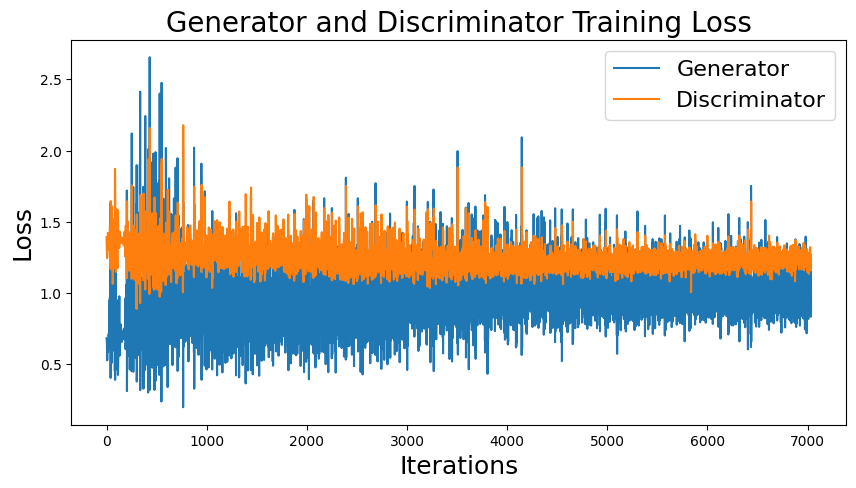

In [ ]:
# Plot training losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Training Loss", fontsize=20)
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations", fontsize=18)
plt.ylabel("Loss", fontsize=18)
plt.legend(fontsize=16)
plt.savefig(f"loss_{dataset_choice}_{nn_choice}.png", bbox_inches="tight", dpi=300)
plt.show()

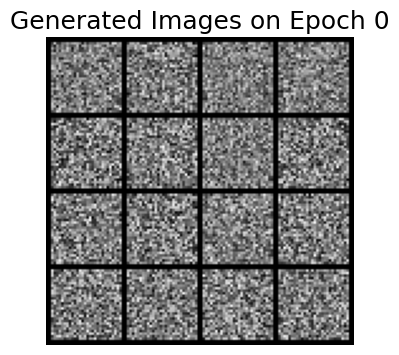

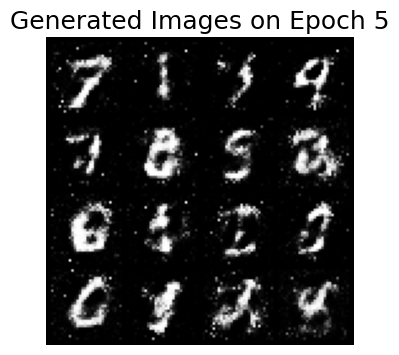

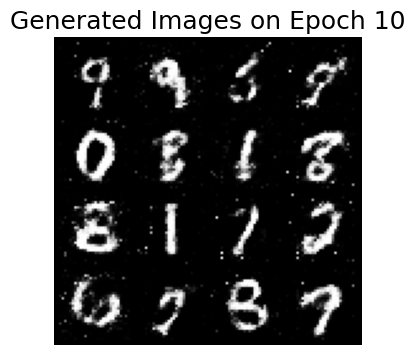

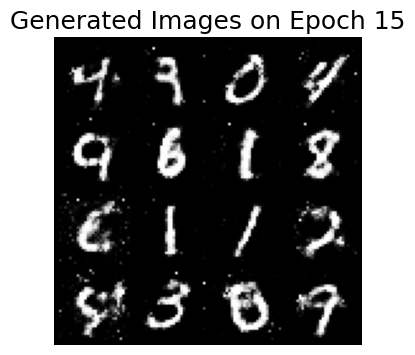

In [ ]:
# Load and visualize images from epochs 0, 5, 10, and 15
import glob

epochs_to_load = [0, 5, 10, 15]  # Epochs to visualize
n_rows = 4  # Number of rows and columns in the image grid
n_images = n_rows ** 2
noise = torch.randn(n_images, z_dim, device=device) + torch.zeros(n_images, z_dim, device=device)

for epoch_to_load in epochs_to_load:
    # Construct the checkpoint file path
    checkpoint_path = f'checkpoints_{dataset_choice}_{nn_choice}/checkpoint_epoch_{epoch_to_load}.pth'

    # Check if the checkpoint exists
    if not os.path.isfile(checkpoint_path):
        print(f"Checkpoint for epoch {epoch_to_load} not found at {checkpoint_path}")
        continue

    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    G.load_state_dict(checkpoint['G_state_dict'])

    # Generate images
    with torch.no_grad():
        fake_images = G(noise).detach().cpu()
        # Reshape images for visualization
        if channels_img == 1:
            fake_images = fake_images.view(-1, 1, image_size, image_size)
        else:
            fake_images = fake_images.view(-1, 3, image_size, image_size)
        # Create a grid of images
        img_grid = utils.make_grid(fake_images, nrow=n_rows, padding=2, normalize=True)
        # Display the images
        plt.figure(figsize=(n_rows,n_rows))
        plt.axis('off')
        plt.title(f'Generated Images on Epoch {epoch_to_load}', fontsize=18)
        plt.imshow(np.transpose(img_grid, (1, 2, 0)))
        plt.savefig(f"image_{dataset_choice}_{nn_choice}_{epoch_to_load}.png", bbox_inches="tight", dpi=300)
        plt.show()